In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
X=6*np.random.rand(100,1)-3
y=0.5*X**2+1.5*X+2+np.random.randn(100,1)
#y=0.5X^2+1.5X+2+outliers

print(X)

[[-3.34968238e-01]
 [-2.92189263e+00]
 [-4.54419242e-01]
 [ 2.31187166e-01]
 [ 1.48373838e-02]
 [ 2.25053273e+00]
 [-1.02694712e+00]
 [-1.82335103e+00]
 [-2.81626332e+00]
 [-2.95277935e+00]
 [-2.02721294e+00]
 [ 2.14899155e+00]
 [-2.00742833e+00]
 [ 5.83655399e-04]
 [-4.30956819e-01]
 [-5.04479233e-01]
 [-7.24554342e-01]
 [ 2.32590034e+00]
 [-1.76504678e+00]
 [-2.05655667e+00]
 [-1.55945085e+00]
 [-2.06267963e+00]
 [ 9.07690078e-01]
 [-8.98343432e-01]
 [ 9.54604774e-01]
 [-2.80280141e+00]
 [-1.90007941e+00]
 [-6.72807214e-01]
 [-1.99224206e+00]
 [ 2.39233235e+00]
 [-9.13101925e-01]
 [ 1.27056976e+00]
 [-9.09689487e-03]
 [ 5.04970385e-01]
 [ 1.19358435e+00]
 [ 2.17398611e+00]
 [ 1.89861988e+00]
 [ 1.21699559e+00]
 [ 1.01178740e+00]
 [ 1.82179596e-01]
 [ 2.75659858e+00]
 [-3.70284211e-01]
 [ 2.06004996e+00]
 [-1.86935009e+00]
 [ 2.03626326e+00]
 [ 2.04735982e+00]
 [-2.87691008e+00]
 [ 2.23627377e+00]
 [ 2.46911298e+00]
 [ 6.75861805e-01]
 [-4.32538627e-01]
 [-2.06836686e+00]
 [-2.7836921

Text(0, 0.5, 'y dataset')

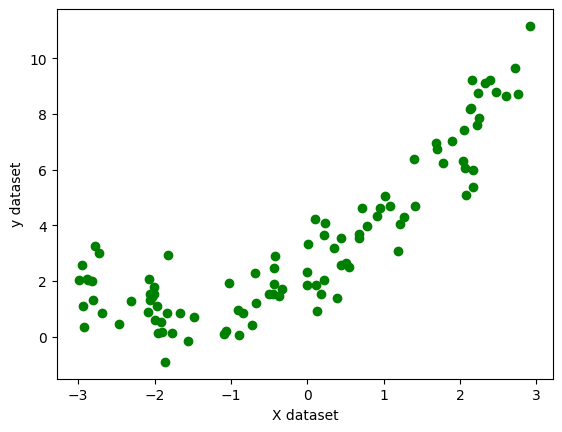

In [4]:
plt.scatter(x=X,y=y,color='g')
plt.xlabel('X dataset')
plt.ylabel('y dataset')

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.33,random_state=42)

In [6]:
## first using the linear regression
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

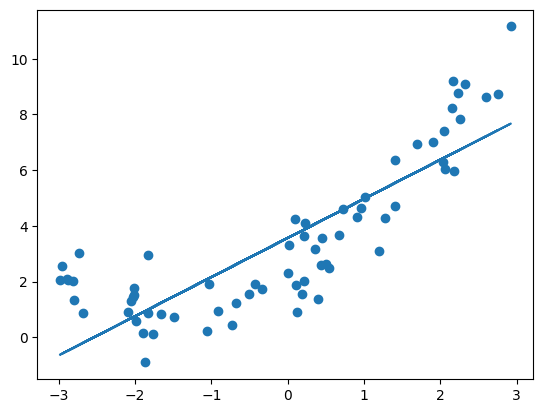

In [7]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regression.predict(X_test))

In [8]:
y_pred=regression.predict(X_test)

In [9]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

2.477775679600763
1.3060607995524094
1.574095193945005


### R square metrics

In [10]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
score

0.6725294190801749

### Adjusted R square metrics

In [11]:
adjusted_r2 = 1 - ((1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))
adjusted_r2

0.6674914101429468

In [12]:
residual=y_test-y_pred
residual

array([[ 0.53463766],
       [ 2.57140999],
       [ 0.04176447],
       [ 0.97834038],
       [-0.11879599],
       [-2.28342859],
       [-0.51210203],
       [-2.82162757],
       [ 0.72571297],
       [-1.3780008 ],
       [-0.96783521],
       [-1.33319343],
       [ 1.07145104],
       [-1.64213315],
       [-1.8511112 ],
       [-0.2700977 ],
       [-1.84609109],
       [-0.2273806 ],
       [ 0.77665341],
       [-1.06309308],
       [-0.84954379],
       [ 3.48820943],
       [-0.73822332],
       [-0.42039775],
       [-1.86417775],
       [-1.31717267],
       [ 1.28938431],
       [-1.86456641],
       [ 3.14368823],
       [ 1.02954318],
       [ 1.63282227],
       [ 2.05584126],
       [-0.64280513],
       [-0.16882264],
       [-0.74558233],
       [ 1.12600099],
       [-2.72721969],
       [-1.60346173],
       [-0.65305096],
       [-2.11257593],
       [-0.83221558],
       [-2.15471426],
       [ 1.93673434],
       [ 1.00013169],
       [-1.4065364 ],
       [ 0

## So as we can see that best fit line is not appropriate for the polynomial equations 

In [13]:
#lets appply polynomial regresssion
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.fit_transform(X_test)

In [14]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred_poly=regression.predict(X_test_poly)

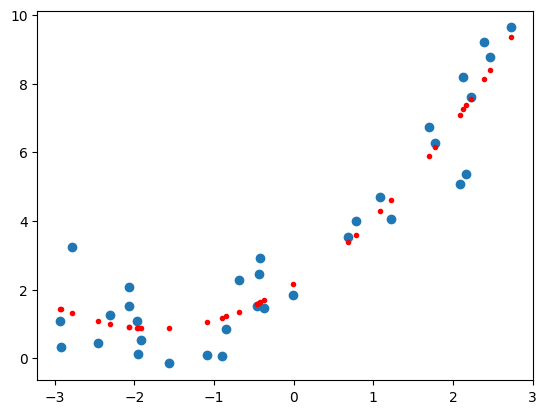

In [15]:
plt.scatter(X_train,y_train)
plt.scatter(X_train,regression.predict(X_train_poly),marker='.',color='red')

### New R square score

In [16]:
score1=r2_score(y_test,y_pred_poly)
score1

0.8916902365185241

### New Adjusted R Square score

In [17]:
adjusted_r2 = 1 - ((1 - score1) * (len(y_test) - 1) / (len(y_test) - X_test_poly.shape[1] - 1))
adjusted_r2

0.8865326287336919

In [18]:
# Now training the data with the degree 3
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.fit_transform(X_test)
X_train

array([[ 2.08296195],
       [ 2.72618379],
       [ 1.77615533],
       [-0.42199693],
       [-0.37028421],
       [-1.95871536],
       [ 2.46911298],
       [-2.93476767],
       [-1.91622112],
       [-1.09181154],
       [-0.00909689],
       [ 2.22247553],
       [ 2.16472004],
       [-2.3086701 ],
       [ 1.69360225],
       [ 1.21699559],
       [ 2.39233235],
       [-2.92189263],
       [-2.78369213],
       [-2.06267963],
       [-0.45441924],
       [-0.89834343],
       [ 0.78311166],
       [ 0.67890331],
       [-0.6884162 ],
       [-2.46024896],
       [-1.96906887],
       [-1.55945085],
       [ 2.13139414],
       [ 1.08465079],
       [-0.43095682],
       [-0.8444829 ],
       [-2.06836686]])

In [19]:
X_test_poly

array([[ 1.00000000e+00,  1.01105582e-01,  1.02223388e-02,
         1.03353552e-03],
       [ 1.00000000e+00, -2.88793956e+00,  8.34019490e+00,
        -2.40859788e+01],
       [ 1.00000000e+00,  7.22139976e-01,  5.21486144e-01,
         3.76585992e-01],
       [ 1.00000000e+00,  2.04735982e+00,  4.19168224e+00,
         8.58188180e+00],
       [ 1.00000000e+00,  2.03626326e+00,  4.14636808e+00,
         8.44309700e+00],
       [ 1.00000000e+00,  1.82179596e-01,  3.31894053e-02,
         6.04643245e-03],
       [ 1.00000000e+00,  9.07690078e-01,  8.23901278e-01,
         7.47847016e-01],
       [ 1.00000000e+00,  1.21542171e-01,  1.47724993e-02,
         1.79548164e-03],
       [ 1.00000000e+00, -2.02721294e+00,  4.10959232e+00,
        -8.33101873e+00],
       [ 1.00000000e+00, -3.34968238e-01,  1.12203720e-01,
        -3.75846825e-02],
       [ 1.00000000e+00, -1.76504678e+00,  3.11539015e+00,
        -5.49880937e+00],
       [ 1.00000000e+00, -9.13101925e-01,  8.33755126e-01,
      

In [20]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred_poly=regression.predict(X_test_poly)


In [21]:
#predicting on new data
X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)
y_new=regression.predict(X_new_poly)

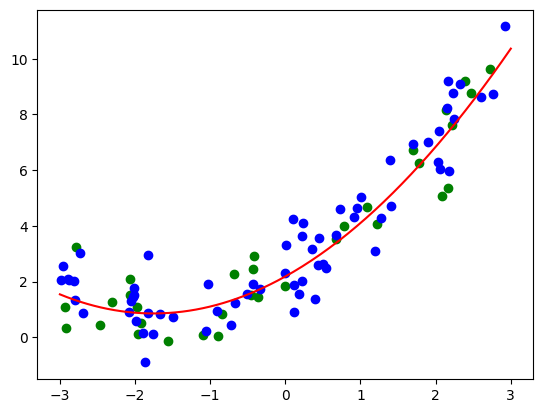

In [22]:
plt.plot(X_new,y_new,"r")
plt.scatter(X_train,y_train,color="green")
plt.scatter(X_test,y_test,color="blue")

In [23]:
regression.coef_

array([[ 0.        ,  1.50371214,  0.4188393 , -0.00364955]])